# Ringkas: Perbandingan ALS & IBCF (Sederhana, MAP@10)
Notebook ini disederhanakan untuk hanya melakukan:
1. Memuat data implicit (user_id, item_id)
2. Split train/test per-user (holdout 20%)
3. Membangun 3 model: ALS Default, ALS Tuned, IBCF Default
4. Evaluasi satu metrik ranking: MAP@10
5. Visualisasi bar chart MAP@10 dan menampilkan 10 rekomendasi (model terbaik MAP@10)

Untuk efisiensi:
- Model IBCF dilatih memakai potongan 100.000 interaksi (train copy subset)
- Model ALS dilatih memakai seluruh data train

Jalankan sel berurutan dari atas untuk mereproduksi hasil.

In [ ]:
# Install and Imports
import sys
import subprocess

# Install implicit if missing
try:
    import implicit  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "implicit"])  # silent-ish install

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from implicit.als import AlternatingLeastSquares as ALS
from implicit.nearest_neighbours import bm25_weight  # light weighting utility

# Deterministic seeds
RNG_SEED = 42
np.random.seed(RNG_SEED)

DATA_PATH = "train.csv"  # relative to `data/` folder for this notebook
K = 10  # top-K rekomendasi per user
IBCF_MAX_INTERACTIONS = 100_000  # batas interaksi untuk pelatihan IBCF
WEIGHTING = "bm25"  # pilihan: "bm25" atau "none"


c:\Users\perak\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load, Encode, Split, and Build Matrices

def load_interactions(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    expected_cols = {"user_id", "item_id"}
    missing = expected_cols - set(df.columns)
    if missing:
        raise ValueError(f"Kolom hilang di {csv_path}: {missing}")
    return df[["user_id", "item_id"]].astype({"user_id": int, "item_id": str})


def encode_ids(df: pd.DataFrame):
    user_codes, user_uniques = pd.factorize(df.user_id, sort=True)
    item_codes, item_uniques = pd.factorize(df.item_id, sort=True)
    return user_codes, item_codes, user_uniques, item_uniques


def train_test_split_by_user(df: pd.DataFrame, test_ratio: float = 0.2, seed: int = 42):
    rng = np.random.default_rng(seed)
    test_rows = []
    keep_rows = []

    # groupby user and holdout per-user
    for uid, g in df.groupby("user_id"):
        items = g.item_id.values
        n = len(items)
        if n <= 1:
            keep_rows.append(g)
            continue
        t = max(1, int(round(test_ratio * n)))
        test_idx = rng.choice(np.arange(n), size=t, replace=False)
        mask = np.ones(n, dtype=bool)
        mask[test_idx] = False
        keep_rows.append(g.iloc[mask])
        test_rows.append(g.iloc[~mask])

    train_df = pd.concat(keep_rows, ignore_index=True)
    test_df = pd.concat(test_rows, ignore_index=True) if test_rows else pd.DataFrame(columns=df.columns)
    return train_df, test_df


def build_user_item(train_df: pd.DataFrame, user_uniques: np.ndarray, item_uniques: np.ndarray):
    # map raw ids to indices
    u_index = pd.Index(user_uniques)
    i_index = pd.Index(item_uniques)
    rows = u_index.get_indexer(train_df.user_id.values)
    cols = i_index.get_indexer(train_df.item_id.values)
    data = np.ones(len(train_df), dtype=np.float32)
    user_items = sp.csr_matrix((data, (rows, cols)), shape=(len(user_uniques), len(item_uniques)))
    return user_items


def build_truth_by_user(test_df: pd.DataFrame) -> dict:
    truth = {}
    for uid, g in test_df.groupby("user_id"):
        truth[int(uid)] = set(g.item_id.values)
    return truth

# Load and prepare data
raw = load_interactions(DATA_PATH)
train_df, test_df = train_test_split_by_user(raw, test_ratio=0.2, seed=RNG_SEED)

# Encode on FULL space to keep consistent index mapping
a_u_codes, a_i_codes, user_uniques, item_uniques = encode_ids(raw)
user_items = build_user_item(train_df, user_uniques, item_uniques)
item_users = user_items.T.tocsr()  # for ALS
truth = build_truth_by_user(test_df)

n_users, n_items = user_items.shape
print(f"Users: {n_users:,} | Items: {n_items:,} | Train interactions: {user_items.nnz:,} | Test users: {len(truth):,}")


Users: 13,876 | Items: 123,069 | Train interactions: 215,489 | Test users: 13,876


In [3]:
# Helpers: Recommendation and Evaluation (MAP@10)

import math

def recommend_topk_for_all(model, user_items: sp.csr_matrix, k: int = 10):
    n_users = user_items.shape[0]
    all_recs = {}
    for u in range(n_users):
        recs, scores = model.recommend(u, user_items[u], N=k, recalculate_user=False)
        all_recs[u] = recs
    return all_recs


def map_at_k(model, user_items: sp.csr_matrix, truth: dict, k: int = 10) -> float:
    if not truth:
        return 0.0
    u_index = pd.Index(user_uniques)
    i_index = pd.Index(item_uniques)
    ap_sum = 0.0
    evaluated = 0
    for u_raw, items_true in truth.items():
        if not items_true:
            continue
        try:
            u_idx = int(u_index.get_loc(u_raw))
        except KeyError:
            continue
        recs, _ = model.recommend(u_idx, user_items[u_idx], N=k, recalculate_user=False)
        items_true_idx = set(i_index.get_indexer(list(items_true)))
        hits = 0
        precision_accum = 0.0
        for rank, item_idx in enumerate(recs, start=1):
            if item_idx in items_true_idx:
                hits += 1
                precision_accum += hits / rank
        if hits > 0:
            ap_sum += precision_accum / min(len(items_true_idx), k)
        evaluated += 1
    return ap_sum / evaluated if evaluated > 0 else 0.0


# Catatan: RMSE dihapus untuk menyederhanakan eksekusi dan menghindari beban memori pada IBCF.

In [ ]:
# Train IBCF (improved, weighted + cosine-style) on subset + Evaluate MAP@10

# 1) Potong data interaksi hingga 100.000 hanya untuk IBCF
n_ibcf = int(min(IBCF_MAX_INTERACTIONS, len(train_df)))
train_df_ibcf = train_df.sample(n=n_ibcf, random_state=RNG_SEED)
print(f"IBCF uses {len(train_df_ibcf):,} interactions (subset of train)")

# 2) Bangun matriks untuk IBCF berdasarkan subset
user_items_ibcf = build_user_item(train_df_ibcf, user_uniques, item_uniques)
item_users_ibcf = user_items_ibcf.T.tocsr()
print(f"user_items_ibcf shape: {user_items_ibcf.shape} | nnz: {user_items_ibcf.nnz:,}")

# 3) Pemberat (BM25) untuk menekan item/popularitas dan meningkatkan signal
if WEIGHTING == "bm25":
    user_items_w = bm25_weight(user_items_ibcf, K1=1.2, B=0.75)
else:
    user_items_w = user_items_ibcf
item_users_w = user_items_w.T.tocsr()

# 4) Normalisasi L2 per baris item (cosine-style)
#    skor ~ (sum v_seen_normalized) @ V_items_normalized.T
row_norms = np.sqrt(item_users_w.multiply(item_users_w).sum(axis=1)).A1 + 1e-9
item_scale = sp.diags(1.0 / row_norms)
item_users_norm = item_scale @ item_users_w  # (items x users)
user_items_norm = item_users_norm.T.tocsr()  # (users x items)

# 5) IBCF Sederhana berbasis kombinasi vektor item ter-normalisasi
class SimpleIBCF:
    def __init__(self, item_users_norm_csr: sp.csr_matrix, user_items_norm_csr: sp.csr_matrix):
        self.item_users_norm = item_users_norm_csr  # (items x users)
        self.user_items_norm = user_items_norm_csr  # (users x items)
        self.user_items_raw = user_items_ibcf       # untuk masking seen

    def recommend(self, u_idx: int, user_row: sp.csr_matrix, N: int = 10, recalculate_user: bool = False):
        seen = self.user_items_raw[u_idx].indices
        if seen.size == 0:
            return np.array([], dtype=int), np.array([], dtype=float)
        # Gabungkan representasi item yang telah dilihat user (1 x users)
        combined = self.item_users_norm[seen, :].sum(axis=0)  # (1 x users)
        # Skor ke semua item: combined (1 x users) @ user_items_norm (users x items)
        scores = combined @ self.user_items_norm
        y = np.asarray(scores).ravel()
        # Mask item yang sudah dilihat
        if seen.size > 0:
            y[seen] = -np.inf
        # Ambil Top-N efisien
        N_eff = min(N, y.size)
        if N_eff <= 0:
            return np.array([], dtype=int), np.array([], dtype=float)
        if N_eff == y.size:
            top = np.argsort(y)[::-1][:N_eff]
        else:
            idx = np.argpartition(y, -N_eff)[-N_eff:]
            top = idx[np.argsort(y[idx])[::-1]]
        return top.astype(int), y[top]

# Fit model sederhana (tanpa precompute full similarity)
ibcf_default = SimpleIBCF(item_users_norm, user_items_norm)

# Evaluasi MAP@K pada subset matriks IBCF
ibcf_def_map = map_at_k(ibcf_default, user_items_ibcf, truth, k=K)
print(f"IBCF Default (weighted+cosine) MAP@{K}: {ibcf_def_map:.4f}")

IBCF uses 100,000 interactions (subset of train)
user_items_ibcf shape: (13876, 123069) | nnz: 100,000
IBCF Default (simple) MAP@10: 0.0018
IBCF Default (simple) MAP@10: 0.0018


In [9]:
# Train ALS (default and tuned) + Evaluate MAP@10
als_default = ALS()
als_default.fit(user_items)
als_def_map = map_at_k(als_default, user_items, truth, k=K)
print(f"ALS Default MAP@{K}: {als_def_map:.4f}")

als_tuned = ALS(factors=300, regularization=0.002, iterations=120, alpha=40)
als_tuned.fit(user_items)
als_tuned_map = map_at_k(als_tuned, user_items, truth, k=K)
print(f"ALS Tuned   MAP@{K}: {als_tuned_map:.4f}")


100%|██████████| 15/15 [01:12<00:00,  4.81s/it]


ALS Default MAP@10: 0.0106


100%|██████████| 120/120 [12:35<00:00,  6.30s/it]



ALS Tuned   MAP@10: 0.0188


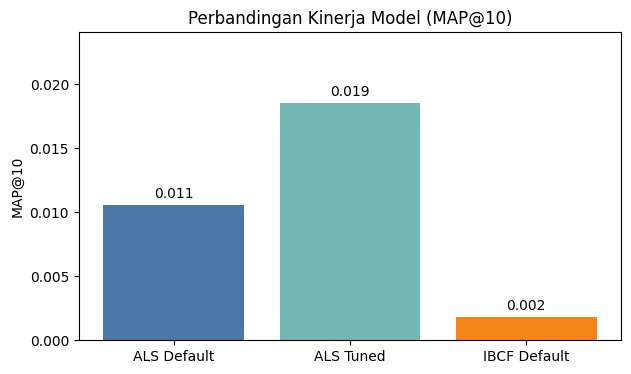

,model,MAP@10
1,ALS Tuned,0.018511
0,ALS Default,0.010589
2,IBCF Default,0.001842


In [7]:
# Compare and Visualize (MAP@10 saja)
labels = ["ALS Default", "ALS Tuned", "IBCF Default"]
map_scores = [als_def_map, als_tuned_map, ibcf_def_map]

plt.figure(figsize=(7,4))
colors = ["#4C78A8", "#72B7B2", "#F58518"]
plt.bar(labels, map_scores, color=colors)
plt.ylabel(f"MAP@{K}")
plt.title("Perbandingan Kinerja Model (MAP@10)")
plt.ylim(0, max(map_scores)*1.3 if max(map_scores)>0 else 0.05)
for i, v in enumerate(map_scores):
    plt.text(i, v + (max(map_scores)*0.03 if max(map_scores)>0 else 0.005), f"{v:.3f}", ha="center")
plt.show()

comparison_df = pd.DataFrame({"model": labels, f"MAP@{K}": map_scores}).sort_values(by=f"MAP@{K}", ascending=False)
comparison_df

In [8]:
# 10 Rekomendasi per User (contoh tampil sebagian) berdasarkan model terbaik MAP@K
best_idx = int(np.argmax([als_def_map, als_tuned_map, ibcf_def_map]))
labels = ["ALS Default", "ALS Tuned", "IBCF Default"]
best_label = labels[best_idx]
print(f"Model terbaik (MAP@{K}): {best_label}")

best_model = {
    "ALS Default": als_default,
    "ALS Tuned": als_tuned,
    "IBCF Default": ibcf_default,
}[best_label]

# Gunakan matriks user-item yang sesuai untuk recommend()
mat_by_label = {
    "ALS Default": user_items,
    "ALS Tuned": user_items,
    "IBCF Default": user_items_ibcf,
}

all_recs_idx = recommend_topk_for_all(best_model, mat_by_label[best_label], k=K)

u_index = pd.Index(user_uniques)
i_index = pd.Index(item_uniques)
rows = []
for u_idx, recs_idx in all_recs_idx.items():
    u_raw = int(u_index[u_idx])
    items_raw = list(i_index[recs_idx])
    rows.append({"user_id": u_raw, "recommendations": items_raw})

recs_df = pd.DataFrame(rows).sort_values("user_id").reset_index(drop=True)
recs_df.head(10)

Model terbaik (MAP@10): ALS Tuned


,user_id,recommendations
0,8,"[0553571885, 0786868716, 8481302651, 155874331..."
1,99,"[0375727345, 0743418174, 0385492081, 037541405..."
2,114,"[0515135062, 0671014196, 0446611212, 044660719..."
3,160,"[0671617028, 0345339681, 052594527X, 184176310..."
4,183,"[0140296409, 9724614565, 9722109030, 972200002..."
5,232,"[0451203895, 059035342X, 0141301155, 006097684..."
6,242,"[3404148665, 3404118960, 3442446783, 345312234..."
7,243,"[0440226430, 0375727345, 0425154092, 037570305..."
8,244,"[0446670111, 039592720X, 0316969443, 014006747..."
9,254,"[0439139600, 0345370775, 0385479565, 031298158..."
